# Load the LSST survey

The aim of this notebook is to show how to load and use the LSST survey like others surveys implemented in `skysurvey`.

***

Using the LSST Opsim (Operations Simulations)) runs (https://usdf-maf.slac.stanford.edu) of your choice (in this example, the last version, baseline_v5.1.0_10yrs.db, is used) and providing the opsim database path, you can simply load LSST with `skysurvey` like this:

In [ ]:
import skysurvey

# lsst opsim files are large, this may take a few minutes 
opsim_path = "baseline_v5.1.0_10yrs.db" # provide fullpath
lsst = skysurvey.LSST.from_opsim(opsim_path)

**Note**:
- Depending on the version of your opsim file, some columns names in the logs may differ. `skysurvey` handles this automatically.

### Survey properties

The survey data contains one row per observation (pointing), with the standard skysurvey columns: `mjd`, `band`, `skynoise`, `gain`, `zp`, plus LSST-specific ones like `observationId`:

In [3]:
lsst.data

,skynoise,mjd,band,gain,zp,ra,dec,observationId,fieldid_survey,fieldid
0,213.274963,60981.003906,lsstr,1,30,263.940186,-25.278366,0,0,337012
1,213.274963,60981.003906,lsstr,1,30,263.940186,-25.278366,0,0,337013
2,213.274963,60981.003906,lsstr,1,30,263.940186,-25.278366,0,0,337014
3,213.274963,60981.003906,lsstr,1,30,263.940186,-25.278366,0,0,337015
4,213.274963,60981.003906,lsstr,1,30,263.940186,-25.278366,0,0,337811
...,...,...,...,...,...,...,...,...,...,...
228139725,125.749084,64632.273438,lsstu,1,30,17.743235,-68.047966,2054480,2054480,464843
228139726,125.749084,64632.273438,lsstu,1,30,17.743235,-68.047966,2054480,2054480,464844
228139727,125.749084,64632.273438,lsstu,1,30,17.743235,-68.047966,2054480,2054480,464845
228139728,125.749084,64632.273438,lsstu,1,30,17.743235,-68.047966,2054480,2054480,464846


The survey spans ~10 years, from the start of LSST operations. We can check the exact date range:

In [4]:
from astropy.time import Time
tmin, tmax = lsst.date_range
print(f"Start: {Time(tmin, format='mjd').iso}")
print(f"End:   {Time(tmax, format='mjd').iso}")
print(f"Duration: {(tmax - tmin)/365.25:.1f} years")

Start: 2025-11-02 00:05:37.500
End:   2035-11-01 06:33:45.000
Duration: 10.0 years


The LSST camera has a roughly circular focal plane with a cross-shaped chip  arrangement (3-5-5-5-3 CCD structure), covering ~9.6 deg². This is the single-field footprint used to match sky positions to observations:

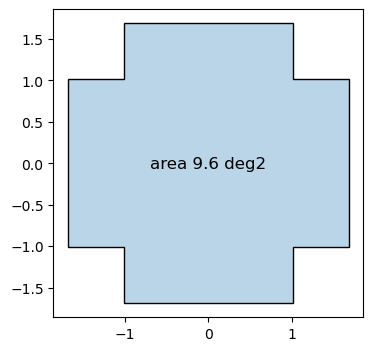

In [5]:
fig = lsst.show_footprint(add_text=True)


We can easily check which filter bands are included in the specific database we're using with:

In [6]:
print(f"Bands covered: {sorted(lsst.data['band'].unique())}")

Bands covered: ['lsstg', 'lssti', 'lsstr', 'lsstu', 'lssty', 'lsstz']


We can visualize the observing cadence (the number of exposures per day), broken down by band. This shows the survey strategy and gaps due to the weather, maintenance, or seasonal gaps.

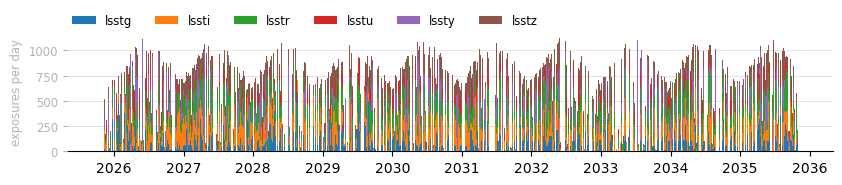

In [7]:
fig = lsst.show_nexposures(exposure_key="observationId") #observationId is LSST's specific exposure_key

### Loading specific subsets

The full 10-year opsim is large (~3M rows). You can load a subset using the `sql_where` argument, which accepts any valid SQLite `WHERE`.

For example, to load the 1rst year of LSST:

In [8]:
lsst_yr1 = skysurvey.LSST.from_opsim(opsim_path, sql_where="night<365")


or just select the u-band:

In [9]:
lsst_y = skysurvey.LSST.from_opsim(opsim_path, sql_where="filter IN ('y')")

You can also combine conditions with `AND`/`OR`, filter by band, night, field, etc. For example, to 
load only the first year excluding the y-band:

In [10]:
lsst_no_y_yr1 = skysurvey.LSST.from_opsim(opsim_path, sql_where="filter IN ('u', 'g', 'r', 'i', 'z') AND night < 365")

We can visualize the sky coverage for the 1rst year of LSST:

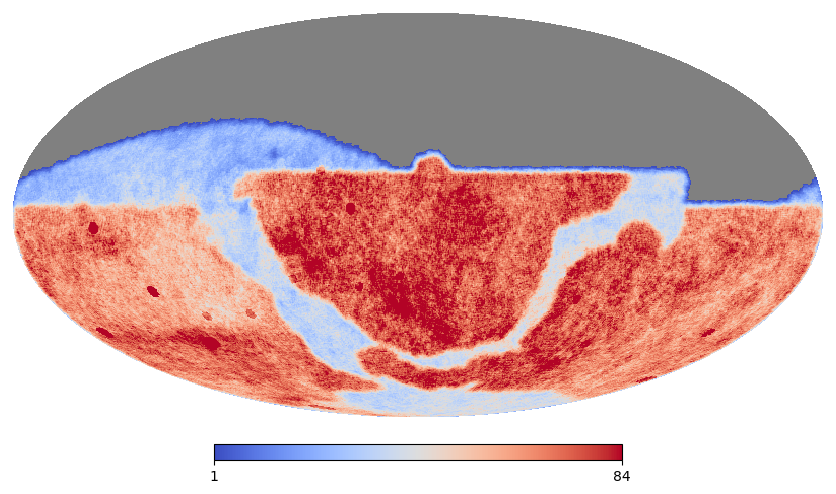

In [11]:
# 5 bands, year 1 
coverage_yr1 = lsst_yr1.get_fieldcoverage()
lsst_yr1.show(vmin=0, vmax=coverage_yr1.quantile(0.95), cmap="coolwarm")

And compare it to the entire duration of the survey:

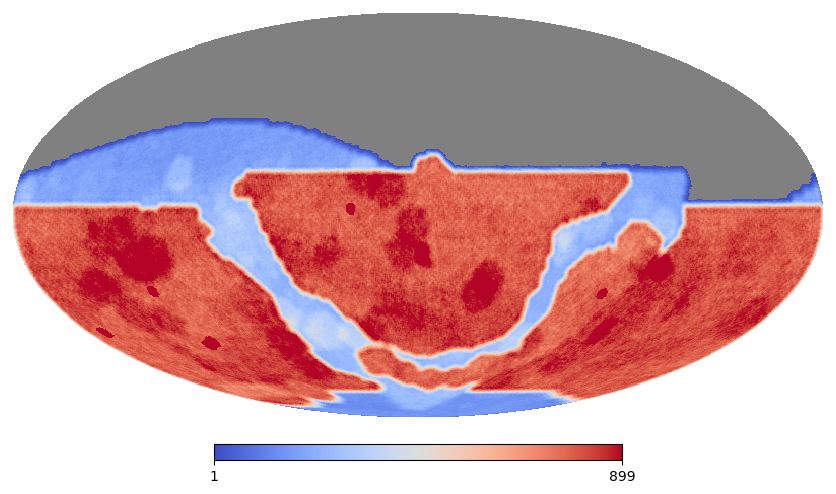

In [12]:
# 6 bands, 10 years
coverage = lsst.get_fieldcoverage()
lsst.show(vmin=0, vmax=coverage.quantile(0.95), cmap="coolwarm")

`get_fieldcoverage()` returns the number of observations per field. Passing it to `show()` via `vmax` controls the color scale. In this example, we use the 95th percentile to enhance the constrast between fields that receive a high number of visits (e.g. deep drilling fields, overlap regions) and less-covered regions.

### Simulate SNe Ia with LSST:

With the survey loaded, we can simulate SNe Ia as they would be observed by LSST. We match the survey time range and set a redshift limit, and simulate 10 000 SNe Ia:

In [13]:
tmin, tmax = lsst.date_range
snia = skysurvey.SNeIa.from_draw(size=10_000, tstart=tmin, tstop=tmax, zmax=0.5)

We generate the observed light curves by matching each SN's position to the LSST pointings. Only a fraction of the 10 000 simulated SNe Ia have light curves, as objects falling outside the survey footprint are automatically excluded.

In [14]:
dset = skysurvey.DataSet.from_targets_and_survey(snia, lsst, progress_bar=True, discard_bands=True)


100%|██████████| 6784/6784 [00:30<00:00, 223.64it/s]


**Note on `discard_bands=True`**: Observations in bands whose wavelength range falls outside the spectral coverage of the defined `sncosmo` model are automatically removed.

This can happen in two cases: 
- **Band redder than model spectral range (low redshift)**: the band’s red edge exceeds the model’s maximum wavelength. This occurs, for example, for LSST’s `lssty` band (9084–10945 Å) when using the SALT2 model at low redshift (z ≲ 0.19), where the model 
  has not yet been sufficiently redshifted to cover the y-band.
  
- **Band bluer than model spectral range (high redshift)**: the band’s blue edge falls below the model’s observer-frame minimum wavelength, which shifts to longer wavelengths as redshift increases. This can affect the `lsstu` band (3105-4086 Å) at high redshift. In simulations extending to z ≈ 2.5, this effect starts to appear around z ≳ 0.6-0.8, becomes common for z ≳ 1.5, and dominates at z ≳ 2, where a significant fraction of observations can be discarded for a given SN. Overall, ~60–80% of simulated SNe Ia have at least one discarded observation due to this effect, with the number of discarded observations per SN varies widely (from a few points to several tens depending on redshift).

In this notebook (z ≤ 0.5), only the first case occurs, affecting a small fraction of the sample (~3–5% of SNe Ia, in the y-band, at low redshift (z ≲ 0.19)).

In [15]:
dset.get_ndetection()

index
3        27
8        14
12       23
14      281
17        4
       ... 
9986     27
9988      3
9994      7
9996     33
9997      4
Length: 3770, dtype: int64

`get_ndetection()` returns the number of 5σ detections per SN Ia. SNe Ia with zero detections are excluded from `dset.data`.

The light curves of a specific SN Ia shows observations in all LSST bands, for the phase range [-20, +40] days:

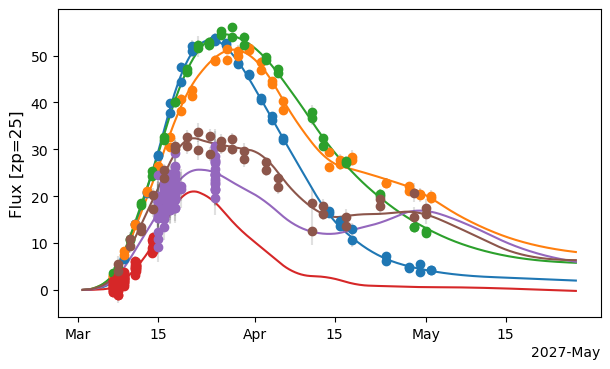

In [57]:
fig = dset.show_target_lightcurve(index=14, phase_window=[-20, 40])

Quality cuts can then be applied to our sample to select SNe Ia with good light curves sampling for a cosmological analysis. A more detailed notebook, "Realistic use of the LSST survey" will be added in the documentation to "Analysis examples" section.